In [2]:
!pip install pandas numpy scikit-learn matplotlib seaborn torch shap

  Using cached numpy-2.2.6-cp312-cp312-macosx_14_0_arm64.whl.metadata (62 kB)
INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 562.3/562.3 kB 1.7 MB/s eta 0:00:00a 0:00:01
Using cached numpy-2.2.6-cp312-cp312-macosx_14_0_arm64.whl (5.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 2.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 2.3 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.42.0
    Uninstalling llvmlite-0.42.0:
      Successfully uninstalled llvmlite-0.42.0
  Attempting uninstall: numba
    Found existing installation: numba 0.59.1
    Uninstalling numba-0.59.1:
      Successfully uninstall

Loading the dataset

In [5]:
import pandas as pd

cols = [
'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent',
'hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root',
'num_file_creations','num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login',
'count','srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate',
'diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count','dst_host_same_srv_rate',
'dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
'dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate',
'label','difficulty'
]

train = pd.read_csv('KDDTrain+.txt', names=cols)
test = pd.read_csv('KDDTest+.txt', names=cols)

print(train.shape)

(125973, 43)


Data Preprocessing 

Label Encoding

In [9]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['protocol_type','service','flag']

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])
    encoders[col] = le

Binary classification (Normal(0) vs Attack(1))

In [14]:
train['label'] = train['label'].apply(lambda x: 0 if x=='normal' else 1)
test['label'] = test['label'].apply(lambda x: 0 if x=='normal' else 1)

Feature Normalization

In [17]:
from sklearn.preprocessing import StandardScaler

X_train = train.drop(['label','difficulty'], axis=1)
y_train = train['label']

X_test = test.drop(['label','difficulty'], axis=1)
y_test = test['label']

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Baseline Model(Logistic Regression)

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.65      0.93      0.77      9711
           1       0.93      0.62      0.74     12833

    accuracy                           0.75     22544
   macro avg       0.79      0.78      0.75     22544
weighted avg       0.81      0.75      0.75     22544



LSTM Model(since attacks often occur in temporal sequences, we employ LSTM to capture sequential dependencies in network traffic)

Data Preprocessing

1.Convert data to sequence format

In [89]:
def create_sequences(X, y, seq_len=30):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train, y_train)
X_test_seq, y_test_seq = create_sequences(X_test, y_test)

print("Sequence shape:", X_train_seq.shape)


Sequence shape: (125943, 30, 41)


In [91]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
X_train_t = torch.tensor(X_train_seq, dtype=torch.float32)
y_train_t = torch.tensor(y_train_seq, dtype=torch.float32)

X_test_t = torch.tensor(X_test_seq, dtype=torch.float32)
y_test_t = torch.tensor(y_test_seq, dtype=torch.float32)


In [93]:
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)


In [95]:
num_pos = (y_train_seq == 1).sum()
num_neg = (y_train_seq == 0).sum()

pos_weight = torch.tensor((num_neg / num_pos)*0.7, dtype=torch.float32)


2.LSTM Model

In [98]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, 128, num_layers=2, batch_first=True)
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(128, 1)

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        out = self.dropout(h[-1])
        return self.fc(out)

model = LSTMModel(X_train_seq.shape[2])
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

3. Training

In [101]:
for epoch in range(30):
    model.train()
    total_loss = 0

    for xb, yb in train_loader:
        outputs = model(xb).squeeze()
        loss = criterion(outputs, yb)

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch}, Loss: {total_loss / len(train_loader)}")


Epoch 0, Loss: 0.616311637820994
Epoch 1, Loss: 0.6159969049134875
Epoch 2, Loss: 0.6159895882616199
Epoch 3, Loss: 0.6158232041975347
Epoch 4, Loss: 0.6155629388806296
Epoch 5, Loss: 0.6151404072477565
Epoch 6, Loss: 0.614255333970475
Epoch 7, Loss: 0.6129699494174825
Epoch 8, Loss: 0.6101927418049758
Epoch 9, Loss: 0.6056121382408026
Epoch 10, Loss: 0.5988935002587675
Epoch 11, Loss: 0.5896559113530608
Epoch 12, Loss: 0.5786419223115696
Epoch 13, Loss: 0.5661463969939851
Epoch 14, Loss: 0.5523872547366513
Epoch 15, Loss: 0.538423399781672
Epoch 16, Loss: 0.524150780985147
Epoch 17, Loss: 0.5099028671478353
Epoch 18, Loss: 0.49519976314793274
Epoch 19, Loss: 0.4820882131353142
Epoch 20, Loss: 0.4677288143070248
Epoch 21, Loss: 0.4550210640924733
Epoch 22, Loss: 0.44195173444544394
Epoch 23, Loss: 0.4299125945331847
Epoch 24, Loss: 0.4189071323328871
Epoch 25, Loss: 0.4083416637154372
Epoch 26, Loss: 0.39875297168103174
Epoch 27, Loss: 0.3904229681711735
Epoch 28, Loss: 0.3813906282837

Model Evaluation

In [103]:
model.eval()

with torch.no_grad():
    outputs = model(X_test_t).squeeze()
    

    preds = (torch.sigmoid(outputs) > 0.5)

print("\nModel Evaluation:\n")
print(classification_report(y_test_seq, preds.numpy()))


Model Evaluation:

              precision    recall  f1-score   support

           0       0.43      0.61      0.51      9696
           1       0.57      0.39      0.46     12818

    accuracy                           0.49     22514
   macro avg       0.50      0.50      0.49     22514
weighted avg       0.51      0.49      0.48     22514



In [105]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test_seq, preds.numpy()))

[[5931 3765]
 [7806 5012]]


Visualizing logistic rgeression model vs LSTM model

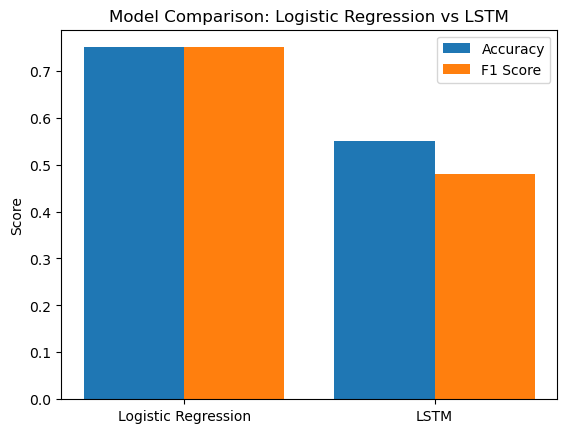

In [108]:
logistic_accuracy = 0.75   
logistic_f1 = 0.75      

lstm_accuracy = 0.55      
lstm_f1 = 0.48            
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'LSTM']
accuracy = [logistic_accuracy, lstm_accuracy]
f1_scores = [logistic_f1, lstm_f1]

x = range(len(models))

plt.figure()
plt.bar(x, accuracy, width=0.4, label='Accuracy')
plt.bar([i + 0.4 for i in x], f1_scores, width=0.4, label='F1 Score')

plt.xticks([i + 0.2 for i in x], models)
plt.ylabel('Score')
plt.title('Model Comparison: Logistic Regression vs LSTM')
plt.legend()

plt.show()